In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df = pd.read_csv('../Dataset/zomato.csv')

In [3]:
df = df.drop(['url','address','book_table','phone','dish_liked','reviews_list','menu_item','listed_in(type)','listed_in(city)','cuisines'],axis=1)

In [4]:
df = df.rename(columns={'approx_cost(for two people)':'approx_cost'})

In [5]:
df = df.fillna(0)

In [6]:
df.approx_cost = df.approx_cost.replace('[,]','', regex= True).astype('int64')

In [7]:
df

,name,online_order,rate,votes,location,rest_type,approx_cost
0,Jalsa,Yes,4.1/5,775,Banashankari,Casual Dining,800
1,Spice Elephant,Yes,4.1/5,787,Banashankari,Casual Dining,800
2,San Churro Cafe,Yes,3.8/5,918,Banashankari,"Cafe, Casual Dining",800
3,Addhuri Udupi Bhojana,No,3.7/5,88,Banashankari,Quick Bites,300
4,Grand Village,No,3.8/5,166,Basavanagudi,Casual Dining,600
...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,3.6 /5,27,Whitefield,Bar,1500
51713,Vinod Bar And Restaurant,No,0,0,Whitefield,Bar,600
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,0,0,Whitefield,Bar,2000
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,4.3 /5,236,"ITPL Main Road, Whitefield",Bar,2500


In [8]:
df.dtypes

name            object
online_order    object
rate            object
votes            int64
location        object
rest_type       object
approx_cost      int64
dtype: object

In [9]:
df.rate = df.rate.replace('-',0)
df.rate = df.rate.replace('NEW',0)
df.rate = df.rate.replace('[/5]','', regex= True).astype('float64')

In [10]:
df

,name,online_order,rate,votes,location,rest_type,approx_cost
0,Jalsa,Yes,4.1,775,Banashankari,Casual Dining,800
1,Spice Elephant,Yes,4.1,787,Banashankari,Casual Dining,800
2,San Churro Cafe,Yes,3.8,918,Banashankari,"Cafe, Casual Dining",800
3,Addhuri Udupi Bhojana,No,3.7,88,Banashankari,Quick Bites,300
4,Grand Village,No,3.8,166,Basavanagudi,Casual Dining,600
...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,3.6,27,Whitefield,Bar,1500
51713,Vinod Bar And Restaurant,No,0.0,0,Whitefield,Bar,600
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,0.0,0,Whitefield,Bar,2000
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,4.3,236,"ITPL Main Road, Whitefield",Bar,2500


In [11]:
df.dtypes

name             object
online_order     object
rate            float64
votes             int64
location         object
rest_type        object
approx_cost       int64
dtype: object

In [12]:
df.groupby('location')['approx_cost'].mean().nlargest(10)

location
Sankey Road         2505.555556
Race Course Road    1309.352518
Lavelle Road        1293.100189
MG Road             1125.490196
Infantry Road       1062.251656
Residency Road       964.888889
Langford Town        883.333333
St. Marks Road       871.306818
Cunningham Road      864.969450
Church Street        834.885764
Name: approx_cost, dtype: float64

In [13]:
df.groupby('location')['rate'].mean().nlargest(5)

location
St. Marks Road          3.854830
Rajarajeshwari Nagar    3.850000
Sankey Road             3.818519
Langford Town           3.807407
Lavelle Road            3.793762
Name: rate, dtype: float64

In [14]:
df.groupby('location')['votes'].sum().nlargest(10)

location
Koramangala 5th Block    2219506
Indiranagar              1196007
Koramangala 4th Block     685156
BTM                       619376
Church Street             594979
JP Nagar                  586593
Lavelle Road              506186
HSR                       499720
Koramangala 7th Block     495324
Jayanagar                 488080
Name: votes, dtype: int64

In [15]:
df.groupby('name')['approx_cost'].sum().nlargest(10)

name
Cafe Coffee Day        81100
Mainland China         74100
Barbeque Nation        65600
Toscano                60700
Hammered               59800
Banjara Melting Pot    56100
Sherlock's Pub         54100
Smoor                  51100
Onesta                 51000
Empire Restaurant      48650
Name: approx_cost, dtype: int64

In [16]:
df.groupby('rest_type')['approx_cost'].sum().nlargest(10)

rest_type
Casual Dining         8125300
Quick Bites           6046860
Cafe                  2286450
Casual Dining, Bar    1420550
Delivery              1120259
Fine Dining            936800
Bar                    869450
Takeaway, Delivery     790206
Dessert Parlor         746240
Lounge                 670850
Name: approx_cost, dtype: int64

In [17]:
df.groupby('rest_type')['rate'].mean().nlargest(10)

rest_type
Bar, Pub                       4.600000
Pub, Cafe                      4.595000
Cafe, Lounge                   4.400000
Fine Dining, Lounge            4.400000
Casual Dining, Irani Cafee     4.373333
Microbrewery, Pub              4.366667
Fine Dining, Microbrewery      4.300000
Microbrewery, Lounge           4.255556
Microbrewery, Bar              4.215385
Casual Dining, Microbrewery    4.206780
Name: rate, dtype: float64

In [18]:
df.groupby('rest_type')['votes'].sum().nlargest(10)

rest_type
Casual Dining          4549477
Quick Bites            1477467
Cafe                   1454783
Casual Dining, Bar     1225408
Casual Dining, Cafe     528752
Bar, Casual Dining      454532
Lounge                  407889
Pub                     405025
Pub, Microbrewery       350648
Cafe, Casual Dining     337753
Name: votes, dtype: int64

['Banashankari' 'Basavanagudi' 'Mysore Road' 'Jayanagar'
 'Kumaraswamy Layout' 'Rajarajeshwari Nagar' 'Vijay Nagar' 'Uttarahalli'
 'JP Nagar' 'South Bangalore' 'City Market' 'Nagarbhavi'
 'Bannerghatta Road' 'BTM' 'Kanakapura Road' 'Bommanahalli' 0
 'CV Raman Nagar' 'Electronic City' 'HSR' 'Marathahalli' 'Sarjapur Road'
 'Wilson Garden' 'Shanti Nagar' 'Koramangala 5th Block'
 'Koramangala 8th Block' 'Richmond Road' 'Koramangala 7th Block'
 'Jalahalli' 'Koramangala 4th Block' 'Bellandur' 'Whitefield'
 'East Bangalore' 'Old Airport Road' 'Indiranagar' 'Koramangala 1st Block'
 'Frazer Town' 'RT Nagar' 'MG Road' 'Brigade Road' 'Lavelle Road'
 'Church Street' 'Ulsoor' 'Residency Road' 'Shivajinagar' 'Infantry Road'
 'St. Marks Road' 'Cunningham Road' 'Race Course Road' 'Commercial Street'
 'Vasanth Nagar' 'HBR Layout' 'Domlur' 'Ejipura' 'Jeevan Bhima Nagar'
 'Old Madras Road' 'Malleshwaram' 'Seshadripuram' 'Kammanahalli'
 'Koramangala 6th Block' 'Majestic' 'Langford Town' 'Central Bangalore

Enter Location Name: Koramangala 4th Block


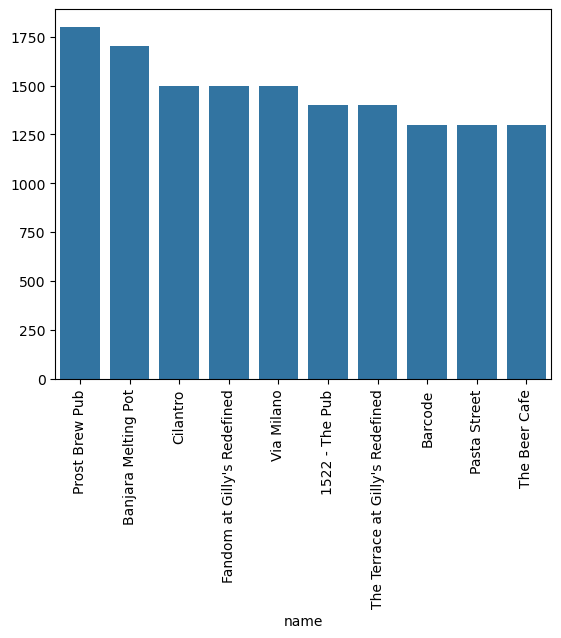

In [19]:
print(df.location.unique())
lo = input("Enter Location Name:")
rest = df[df.location==lo]
a = rest.groupby('name')['approx_cost'].mean().nlargest(10)


sb.barplot(x=a.index, y=a.values)
plt.xticks(rotation=90)
plt.show()